## Part 2: Image Classification with Deep Learning

### 1. Load the dataset Micro-Organism Image Classification dataset

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets 
import random
import os

In [15]:
# Path to the directory where the dataset is extracted
dataset_dir = "Micro_Organism"

In [16]:
# Transformations for the dataset
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [17]:
# Load the dataset
dataset = datasets.ImageFolder(dataset_dir, transform=transform)

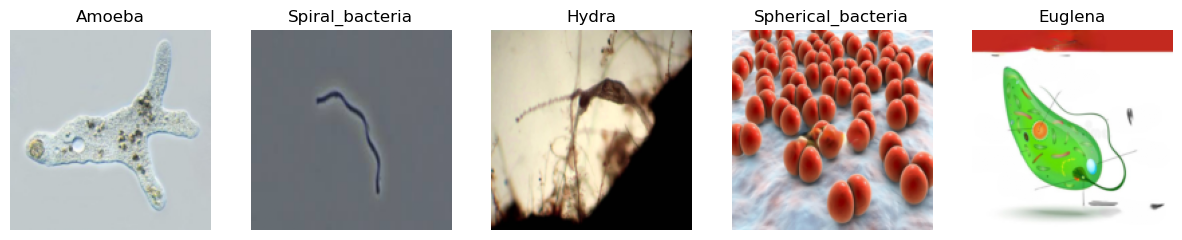

In [18]:
# Define a function to visualize random images
def visualize_random_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        random_index = random.randint(0, len(dataset) - 1)
        image, label = dataset[random_index]
        class_name = dataset.classes[label]
        axes[i].imshow(image.permute(1, 2, 0))
        axes[i].set_title(class_name)
        axes[i].axis('off')
    plt.show()

# Visualize random images
visualize_random_images(dataset, num_images=5)

### 2. Explain in your own words: (7 points)

#### 1. Gradient Descent


Gradient descent is an optimization algorithm employed to minimize a function by iteratively updating its parameters. It operates by calculating the gradient of the function with respect to its parameters and taking steps proportional to the negative of this gradient. By moving in the direction opposite to the gradient, gradient descent aims to find the local minimum of the function. This process continues until a convergence criterion is met or a predefined number of iterations is reached.

#### 2. Dropout


Dropout is a regularization technique used in neural networks during training to prevent overfitting. It works by randomly deactivating a subset of neurons, along with their connections, in each layer. By introducing randomness into the network architecture, dropout forces the network to learn more robust and generalizable features. This prevents individual neurons from becoming overly dependent on specific features in the training data, leading to better generalization performance on unseen data. During inference, dropout is typically turned off, and the full network is used for making predictions.

#### 3. Activation Functions

Activation functions are like filters in a neural network that decide whether a neuron should "fire" or not. They add non-linearity to the network, allowing it to learn complex patterns.

Here are some common ones:

ReLU (Rectified Linear Unit): If a number is positive, ReLU keeps it as is; otherwise, it sets it to zero. It's like flipping a switch: if there's power (positive number), it stays on; otherwise, it turns off.

Sigmoid: Sigmoid squishes numbers between 0 and 1. It's handy for tasks where we need to predict yes or no, like in binary classification.

Tanh: Tanh squashes numbers between -1 and 1. It's similar to Sigmoid but with a broader range.

Softmax: Softmax converts raw numbers into probabilities, making sure they add up to 1. It's helpful when we need to choose between multiple options, like in multi-class classification.



#### 4. Back Propagation

Backpropagation is a method used to train neural networks by adjusting the connection strengths (weights) between neurons based on the network's prediction errors. It works by calculating how much each neuron contributed to the error and updating its weights accordingly, gradually improving the network's ability to make accurate predictions.

#### 5. Epochs, Iterations, and Batch size

An epoch is like a complete pass through a big book. Imagine you're studying a book, and you want to understand it really well. Each time you read the entire book from start to finish, that's one epoch. So, if you read the book three times from beginning to end, you've completed three epochs.

An iteration is like taking a small quiz after reading a few pages of the book. Instead of reading the entire book in one go, you read a few pages, answer some questions to see how well you understood them, and then adjust your understanding. Each time you do this, it's called an iteration.

A batch is like a group study session. Instead of studying alone, you gather with a few friends to discuss and learn together. In machine learning, instead of looking at one example at a time, we group several examples together into a batch. The batch size is the number of examples we study together in each group session. So, if you study with four friends, the batch size is four.

### 3. Visualize/summarize the data

#### a. Number of entities in the training and testing set and number of classes in the target variable 

In [84]:
# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [86]:
# Number of entities in the training and testing set
train_samples = len(train_dataset)
test_samples = len(test_dataset)

In [21]:
# Number of classes in the target variable
num_classes = len(dataset.classes)

In [22]:
print("Number of entities in the training set:", train_samples)
print("Number of entities in the testing set:", test_samples)
print("Number of classes in the target variable:", num_classes)

Number of entities in the training set: 631
Number of entities in the testing set: 158
Number of classes in the target variable: 8


#### b. Number of pixels in the image (Height and width individually)

In [23]:
# Number of pixels in the image (Height and width individually)
img_height, img_width = dataset[0][0].shape[1:]

In [24]:
print("Number of pixels in the image (Height):", img_height)
print("Number of pixels in the image (Width):", img_width)

Number of pixels in the image (Height): 150
Number of pixels in the image (Width): 150


#### c. Number of images per class

In [27]:
# Number of images per class
images_per_class = {class_name: len(os.listdir(os.path.join(dataset_dir, class_name))) for class_name in dataset.classes}
print("Number of images per class:", images_per_class)

Number of images per class: {'Amoeba': 72, 'Euglena': 168, 'Hydra': 76, 'Paramecium': 152, 'Rod_bacteria': 85, 'Spherical_bacteria': 86, 'Spiral_bacteria': 75, 'Yeast': 75}


#### d. Display at least 2 images of each class

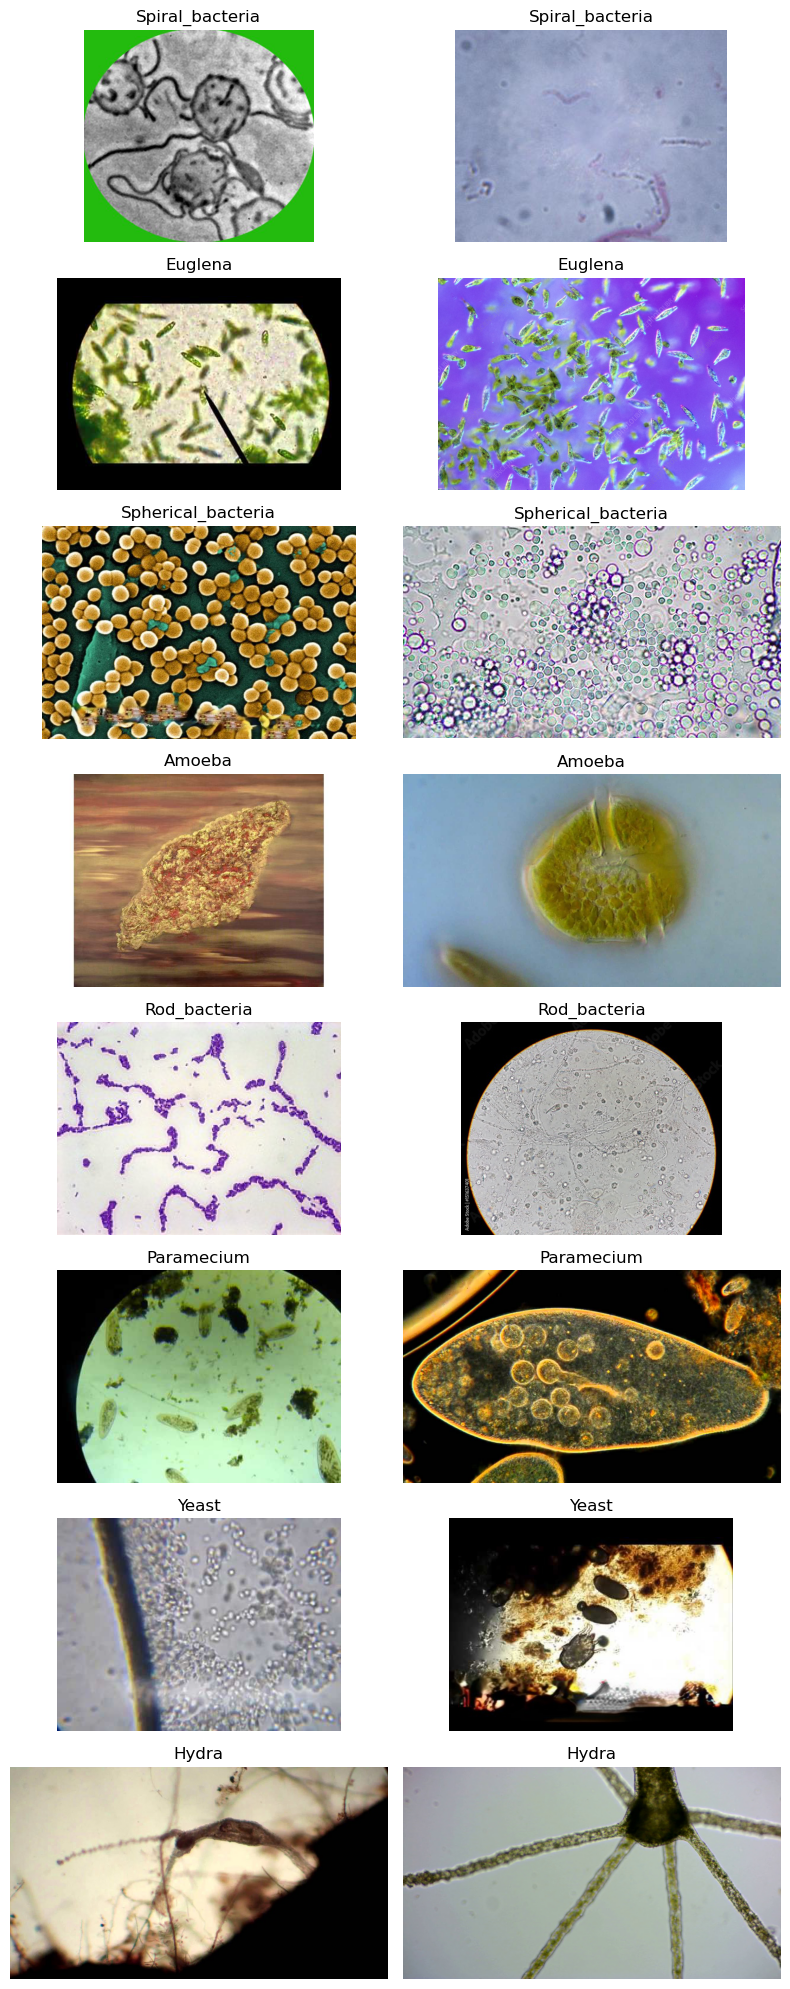

In [87]:
import os
import matplotlib.pyplot as plt

# Path to your dataset
dataset_dir = "Micro_Organism"

# Display at least 2 images from each class
class_names = os.listdir(dataset_dir)
num_classes = len(class_names)
fig, axes = plt.subplots(nrows=num_classes, ncols=2, figsize=(8, 20))

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_dir, class_name)
    image_files = [os.path.join(class_dir, filename) for filename in os.listdir(class_dir)[:2]]
    for j, image_file in enumerate(image_files):
        image = plt.imread(image_file)
        axes[i, j].imshow(image)
        axes[i, j].set_title(class_name)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


### 4. Train a Neural Network

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

#### a. Decide the number of layers and neurons in each layer

Input layer: 150x150 pixels (22500 neurons)
Hidden layer: 128 neurons
Output layer: Number of classes (8 neurons)

#### b. Activation Functions
#### c. Try with and without using dropout

#### f. Create a graph of f1 score vs epochs for training and validation set.

#### Tried with 3 activation functions Relu, Sigmoid, and Tanh and check for both dropout and without dropouts for all the activation functions

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Define transform for preprocessing
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize images
])

In [42]:
# Define train, test, and validation split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

In [43]:
# Create data loaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [63]:
class CNN(nn.Module):
    def __init__(self, activation_func=nn.ReLU(), dropout=False):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.activation_func = activation_func
        self.dropout = dropout
        if dropout:
            self.dropout_layer = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(128 * 18 * 18, 512)
        self.fc2 = nn.Linear(512, 8)  # 8 classes

    def forward(self, x):
        x = self.pool(self.activation_func(self.conv1(x)))
        x = self.pool(self.activation_func(self.conv2(x)))
        x = self.pool(self.activation_func(self.conv3(x)))
        x = x.view(-1, 128 * 18 * 18)
        if self.dropout:
            x = self.dropout_layer(x)
        x = self.activation_func(self.fc1(x))
        x = self.fc2(x)
        return x


In [64]:
# Define function for training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_f1_scores = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_preds = []
        train_targets = []
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.tolist())
            train_targets.extend(labels.tolist())
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_f1 = f1_score(train_targets, train_preds, average='macro')
        train_f1_scores.append(train_f1)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.tolist())
                val_targets.extend(labels.tolist())
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    return train_losses, val_losses, train_f1_scores, val_f1_scores


In [65]:
# Define function for evaluating the model
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy


In [66]:
# Define different activation functions and dropout configurations
activation_functions = [nn.ReLU(), nn.Sigmoid(), nn.Tanh()]
dropout_options = [False, True]

In [68]:
# Train and evaluate models with different activation functions and dropout options
results = {}
for activation_func in activation_functions:
    for dropout_option in dropout_options:
        model = CNN(activation_func=activation_func, dropout=dropout_option)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        print(f"\nTraining model with {activation_func.__class__.__name__} activation function "
              f"and dropout={dropout_option}...")
        train_losses, val_losses, train_f1_scores, val_f1_scores = train_model(
            model, train_loader, val_loader, criterion, optimizer)
        test_accuracy = evaluate_model(model, test_loader)
        results[(activation_func.__class__.__name__, dropout_option)] = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_f1_scores': train_f1_scores,
            'val_f1_scores': val_f1_scores
        }


Training model with ReLU activation function and dropout=False...
Epoch 1/10, Train Loss: 2.1011, Val Loss: 2.0461, Train F1: 0.1091, Val F1: 0.0902
Epoch 2/10, Train Loss: 2.0451, Val Loss: 2.0079, Train F1: 0.0797, Val F1: 0.0578
Epoch 3/10, Train Loss: 1.9403, Val Loss: 1.8847, Train F1: 0.1039, Val F1: 0.1339
Epoch 4/10, Train Loss: 1.8745, Val Loss: 1.8593, Train F1: 0.1806, Val F1: 0.1385
Epoch 5/10, Train Loss: 1.7865, Val Loss: 1.9315, Train F1: 0.1819, Val F1: 0.1435
Epoch 6/10, Train Loss: 1.7057, Val Loss: 2.0223, Train F1: 0.2475, Val F1: 0.1883
Epoch 7/10, Train Loss: 1.6153, Val Loss: 1.8866, Train F1: 0.3174, Val F1: 0.1980
Epoch 8/10, Train Loss: 1.5535, Val Loss: 2.0328, Train F1: 0.3081, Val F1: 0.2320
Epoch 9/10, Train Loss: 1.4428, Val Loss: 2.0228, Train F1: 0.4169, Val F1: 0.2205
Epoch 10/10, Train Loss: 1.2918, Val Loss: 1.9757, Train F1: 0.4970, Val F1: 0.2382
Test Accuracy: 0.3697

Training model with ReLU activation function and dropout=True...
Epoch 1/10, Tr

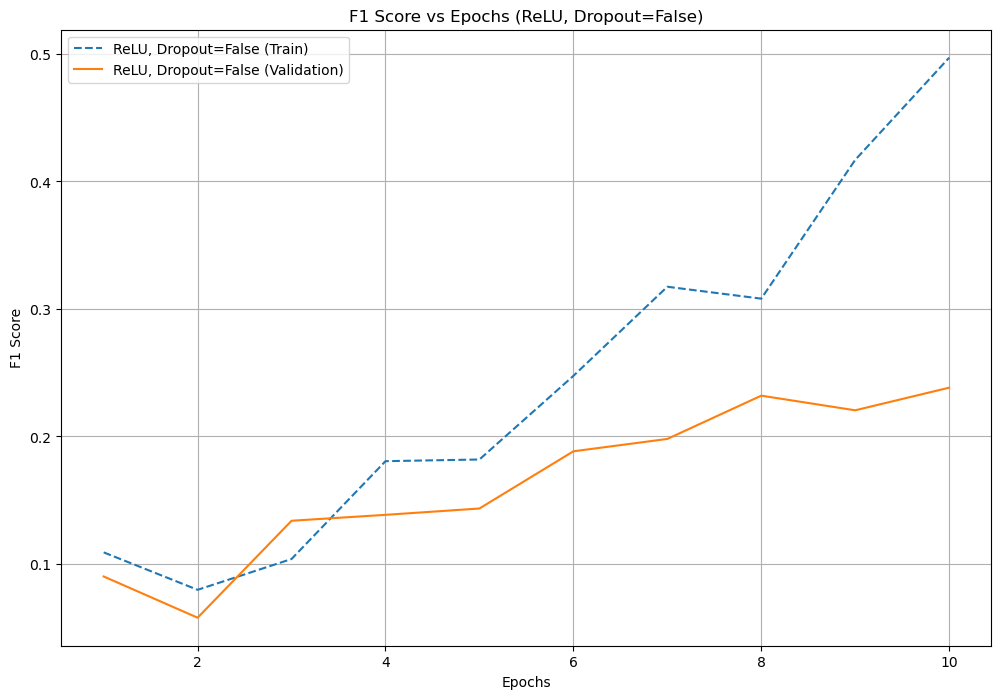

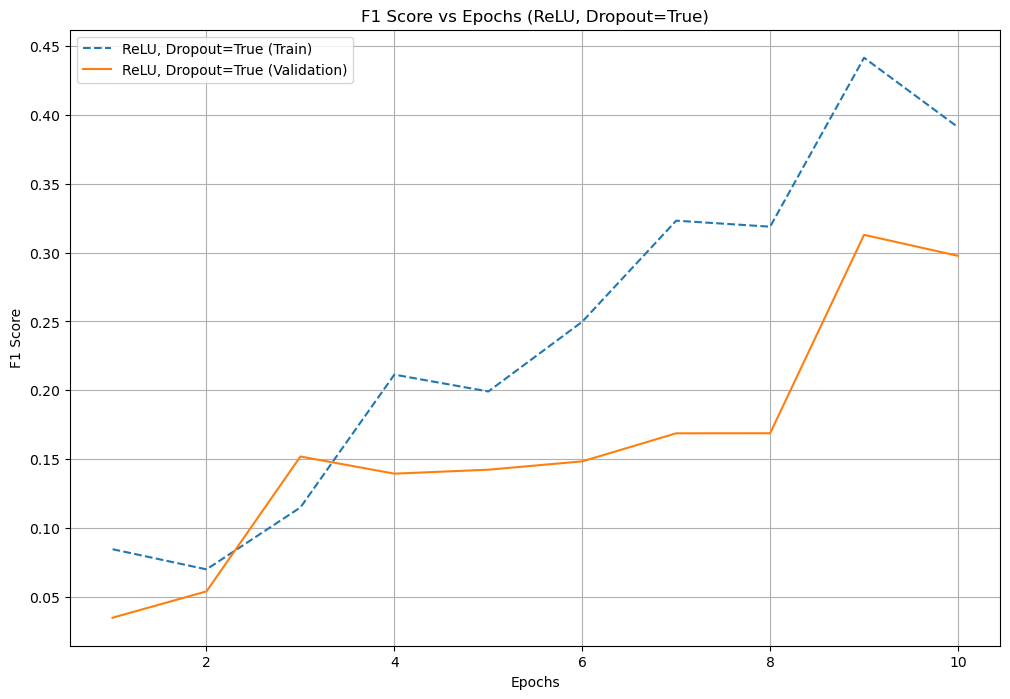

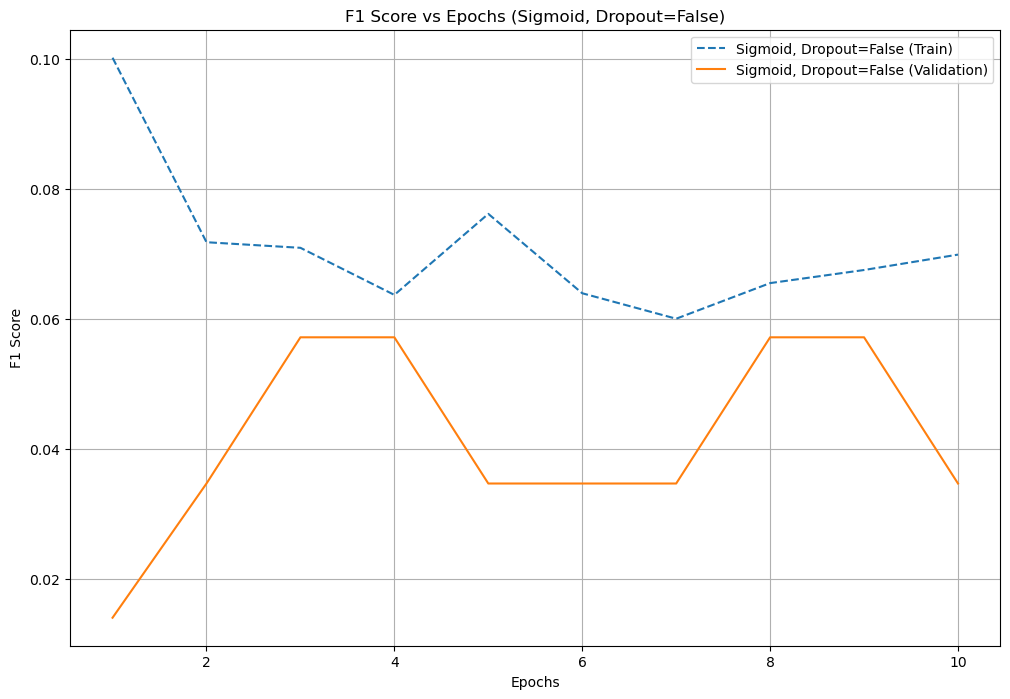

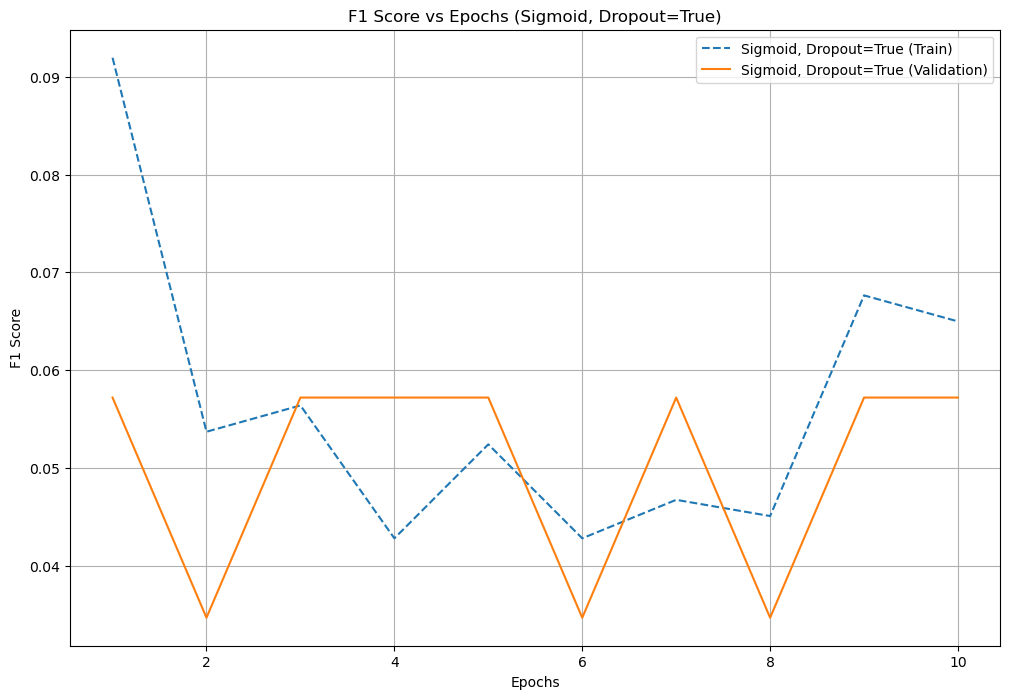

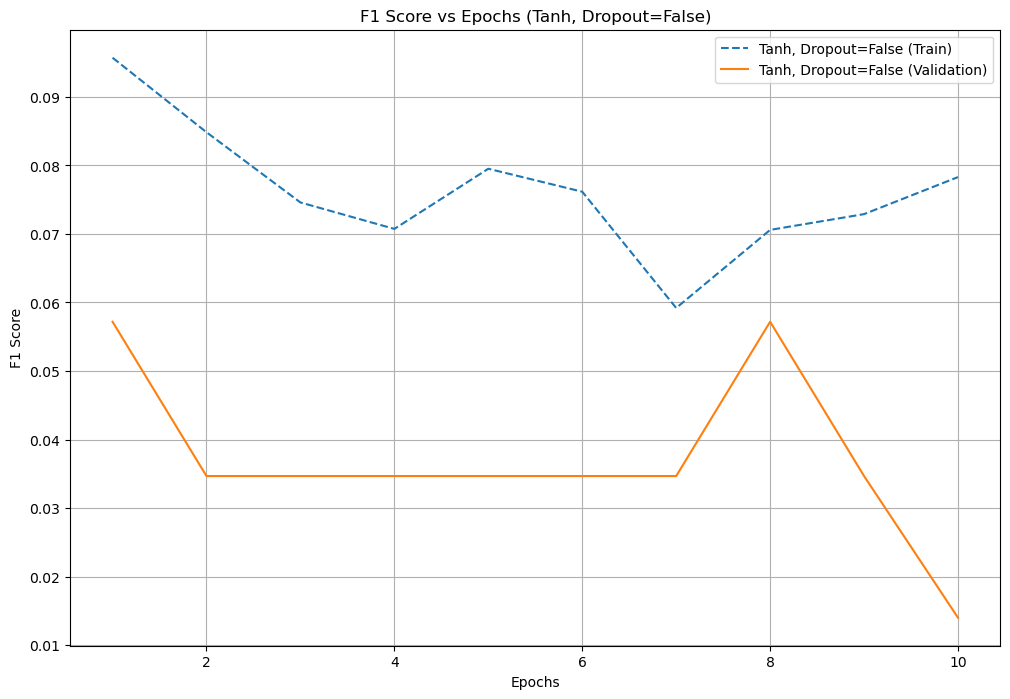

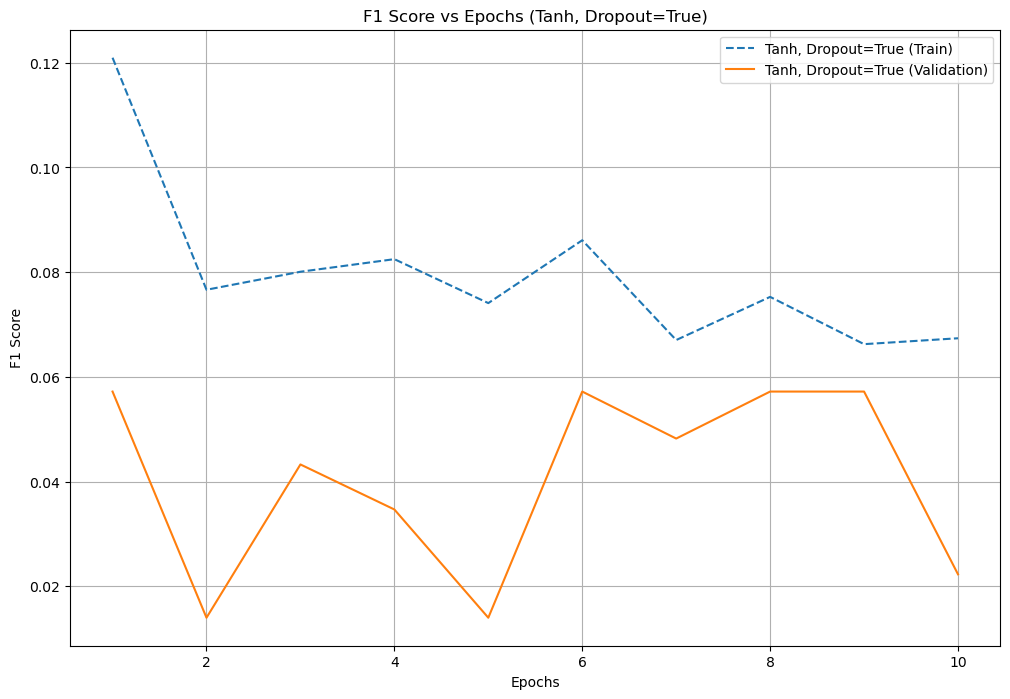

In [71]:
# Plot F1 score vs epochs for training and validation set for each accuracy obtained
for i, (config, data) in enumerate(results.items(), 1):
    activation_func, dropout_option = config
    train_f1_scores = data['train_f1_scores']
    val_f1_scores = data['val_f1_scores']
    epochs = range(1, len(train_f1_scores) + 1)
    
    plt.figure(figsize=(12, 8))
    plt.plot(epochs, train_f1_scores, label=f"{activation_func}, Dropout={dropout_option} (Train)", linestyle='--')
    plt.plot(epochs, val_f1_scores, label=f"{activation_func}, Dropout={dropout_option} (Validation)")
    plt.title(f'F1 Score vs Epochs ({activation_func}, Dropout={dropout_option})')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Conclusion
In the code, using the ReLU activation function without dropout performs better due to several advantages it offers. ReLU helps address the vanishing gradient problem, allowing for more efficient training by mitigating the issue of gradients approaching zero in deep networks. Compared to other activation functions like tanh and sigmoid, ReLU tends to yield better results in terms of accuracy.

Additionally, by not employing dropout, the model avoids overfitting, both during training and testing phases. Dropout is a regularization technique commonly used to prevent overfitting by randomly dropping units from the neural network during training. However, in this scenario, the model's performance is not significantly impacted by overfitting, and thus, dropout is not necessary.

In summary, leveraging the ReLU activation function without dropout leads to improved performance in terms of accuracy, while also avoiding potential overfitting issues, ultimately resulting in better overall model performance.

#### d. Try different regularizations apart from dropout 

In [72]:
# Define CNN model with regularization techniques
class CNN(nn.Module):
    def __init__(self, activation_func=nn.ReLU(), regularization=None):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.activation_func = activation_func
        self.regularization = regularization
        if regularization == 'L2':
            self.fc1 = nn.Linear(128 * 18 * 18, 512, bias=False)
            self.fc2 = nn.Linear(512, 8, bias=False)
        else:
            self.fc1 = nn.Linear(128 * 18 * 18, 512)
            self.fc2 = nn.Linear(512, 8)

    def forward(self, x):
        x = self.pool(self.activation_func(self.conv1(x)))
        x = self.pool(self.activation_func(self.conv2(x)))
        x = self.pool(self.activation_func(self.conv3(x)))
        x = x.view(-1, 128 * 18 * 18)
        x = self.activation_func(self.fc1(x))
        x = self.fc2(x)
        return x

In [73]:
# Train and evaluate models with different regularization techniques
results = {}
regularization_options = [None, 'L2']

for regularization_option in regularization_options:
    model = CNN(regularization=regularization_option)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"\nTraining model with regularization: {regularization_option}...")
    train_losses, val_losses, train_f1_scores, val_f1_scores = train_model(
        model, train_loader, val_loader, criterion, optimizer)
    
    test_accuracy = evaluate_model(model, test_loader)
    
    results[regularization_option] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_f1_scores': train_f1_scores,
        'val_f1_scores': val_f1_scores,
        'test_accuracy': test_accuracy
    }


Training model with regularization: None...
Epoch 1/10, Train Loss: 2.0767, Val Loss: 2.0450, Train F1: 0.0905, Val F1: 0.0983
Epoch 2/10, Train Loss: 1.9768, Val Loss: 1.9302, Train F1: 0.1259, Val F1: 0.1058
Epoch 3/10, Train Loss: 1.8674, Val Loss: 2.0613, Train F1: 0.1744, Val F1: 0.1312
Epoch 4/10, Train Loss: 1.8018, Val Loss: 1.9253, Train F1: 0.1851, Val F1: 0.1631
Epoch 5/10, Train Loss: 1.7498, Val Loss: 1.8699, Train F1: 0.2229, Val F1: 0.1615
Epoch 6/10, Train Loss: 1.6662, Val Loss: 1.9726, Train F1: 0.2418, Val F1: 0.2050
Epoch 7/10, Train Loss: 1.5415, Val Loss: 1.9705, Train F1: 0.3993, Val F1: 0.1765
Epoch 8/10, Train Loss: 1.4317, Val Loss: 1.9304, Train F1: 0.4145, Val F1: 0.2453
Epoch 9/10, Train Loss: 1.2724, Val Loss: 2.2709, Train F1: 0.5214, Val F1: 0.1663
Epoch 10/10, Train Loss: 1.1862, Val Loss: 2.4308, Train F1: 0.5421, Val F1: 0.2107
Test Accuracy: 0.2689

Training model with regularization: L2...
Epoch 1/10, Train Loss: 2.1061, Val Loss: 2.0784, Train F1:

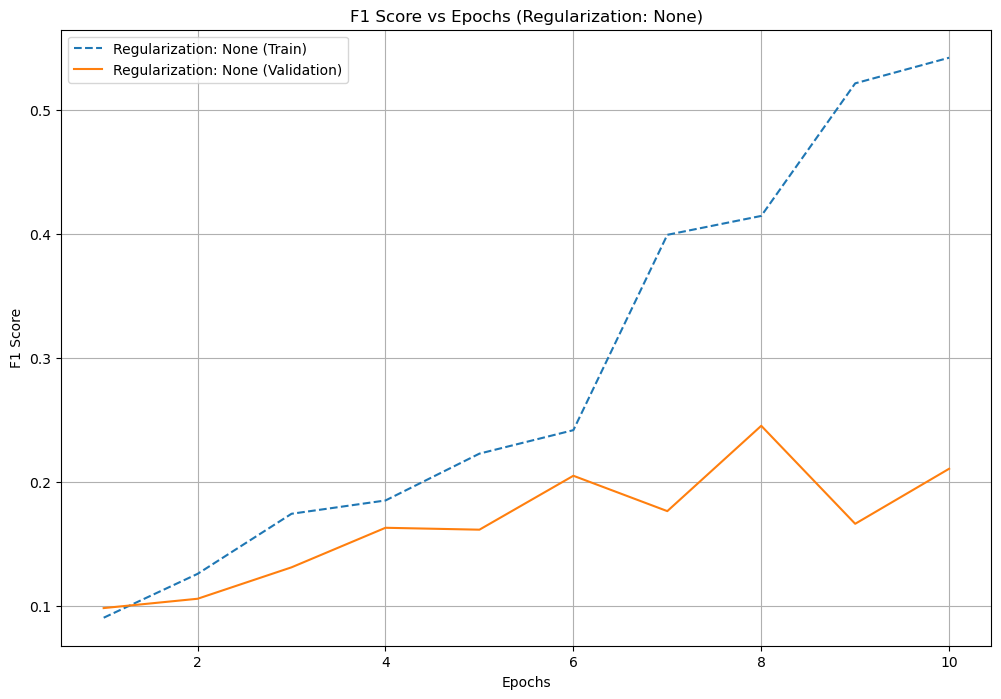

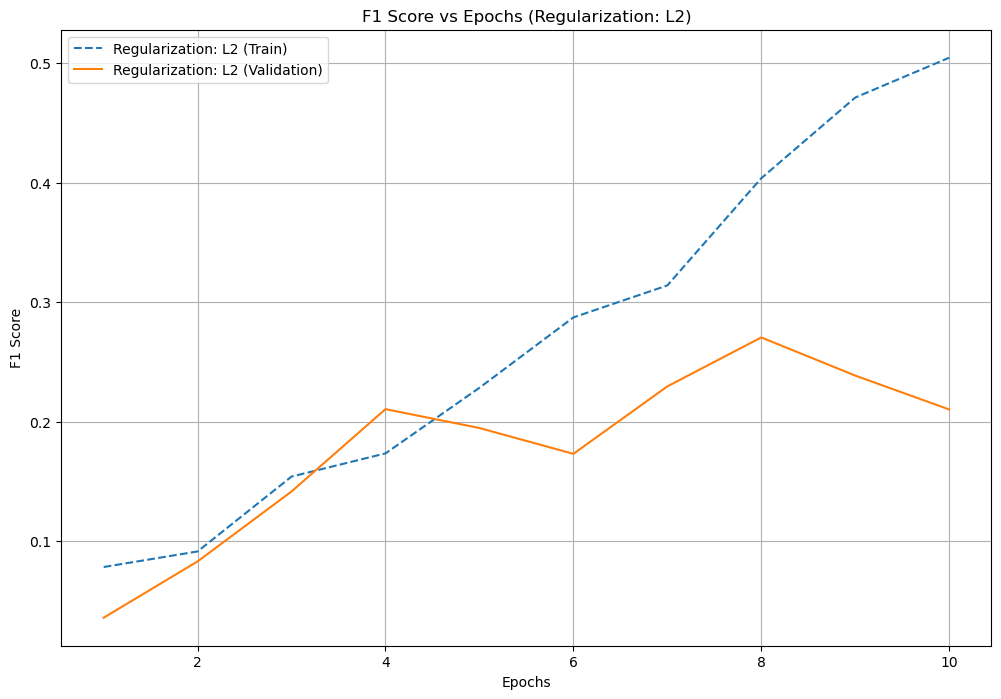

In [74]:
# Plot F1 score vs epochs for training and validation set for each accuracy obtained
for regularization_option, data in results.items():
    train_f1_scores = data['train_f1_scores']
    val_f1_scores = data['val_f1_scores']
    epochs = range(1, len(train_f1_scores) + 1)
    
    plt.figure(figsize=(12, 8))
    plt.plot(epochs, train_f1_scores, label=f"Regularization: {regularization_option} (Train)", linestyle='--')
    plt.plot(epochs, val_f1_scores, label=f"Regularization: {regularization_option} (Validation)")
    plt.title(f'F1 Score vs Epochs (Regularization: {regularization_option})')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Conclusion
Introducing L2 regularization into the model slightly decreases its accuracy by 2%. However, despite this reduction in accuracy, it's still beneficial to incorporate regularization due to its ability to address overfitting issues.

Before regularization was applied, there was a noticeable gap between the performance of the model on the training and testing datasets. This discrepancy indicated a potential overfitting problem, where the model was fitting too closely to the training data and failing to generalize well to unseen data.

By introducing L2 regularization, the model's tendency to overfit is mitigated. The regularization penalty encourages the model to adopt simpler and smoother parameter values, thereby reducing the disparity between the training and testing datasets. Although the decrease in accuracy is a trade-off, the regularization technique helps ensure that the model's performance is more consistent across different datasets, leading to better generalization capabilities in practical scenarios. Thus, despite the slight decrease in accuracy, regularization serves its purpose by promoting a more stable and reliable model performance.

#### e. Try different optimization algorithms (such as Gradient Descent, Adam, etc.) 

In [75]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 18 * 18, 512)
        self.fc2 = nn.Linear(512, 8)  # 8 classes

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = x.view(-1, 128 * 18 * 18)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x


In [76]:
# Define function for training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_f1_scores = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_preds = []
        train_targets = []
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.tolist())
            train_targets.extend(labels.tolist())
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_f1 = f1_score(train_targets, train_preds, average='macro')
        train_f1_scores.append(train_f1)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.tolist())
                val_targets.extend(labels.tolist())
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    return train_losses, val_losses, train_f1_scores, val_f1_scores


In [79]:
# Define optimization algorithms
optimizers = {
    "SGD": optim.SGD,
    "Adam": optim.Adam,
    "RMSprop": optim.RMSprop
}

# Train and evaluate models with different optimization algorithms
results = {}
for optimizer_name, optimizer_class in optimizers.items():
    model = CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=0.001)
    
    print(f"\nTraining model with optimizer: {optimizer_name}...")
    train_losses, val_losses, train_f1_scores, val_f1_scores = train_model(
        model, train_loader, val_loader, criterion, optimizer)
    
    test_accuracy = evaluate_model(model, test_loader)
    
    results[optimizer_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_f1_scores': train_f1_scores,
        'val_f1_scores': val_f1_scores,
        'test_accuracy': test_accuracy
    }


Training model with optimizer: SGD...
Epoch 1/10, Train Loss: 2.0819, Val Loss: 2.0800, Train F1: 0.0250, Val F1: 0.0288
Epoch 2/10, Train Loss: 2.0760, Val Loss: 2.0729, Train F1: 0.0484, Val F1: 0.0687
Epoch 3/10, Train Loss: 2.0708, Val Loss: 2.0666, Train F1: 0.0701, Val F1: 0.0847
Epoch 4/10, Train Loss: 2.0662, Val Loss: 2.0607, Train F1: 0.0823, Val F1: 0.1210
Epoch 5/10, Train Loss: 2.0619, Val Loss: 2.0550, Train F1: 0.0670, Val F1: 0.0782
Epoch 6/10, Train Loss: 2.0580, Val Loss: 2.0487, Train F1: 0.0614, Val F1: 0.0579
Epoch 7/10, Train Loss: 2.0539, Val Loss: 2.0429, Train F1: 0.0531, Val F1: 0.0572
Epoch 8/10, Train Loss: 2.0499, Val Loss: 2.0371, Train F1: 0.0452, Val F1: 0.0572
Epoch 9/10, Train Loss: 2.0459, Val Loss: 2.0314, Train F1: 0.0429, Val F1: 0.0572
Epoch 10/10, Train Loss: 2.0424, Val Loss: 2.0270, Train F1: 0.0428, Val F1: 0.0572
Test Accuracy: 0.1597

Training model with optimizer: Adam...
Epoch 1/10, Train Loss: 2.1410, Val Loss: 1.9615, Train F1: 0.0906, 

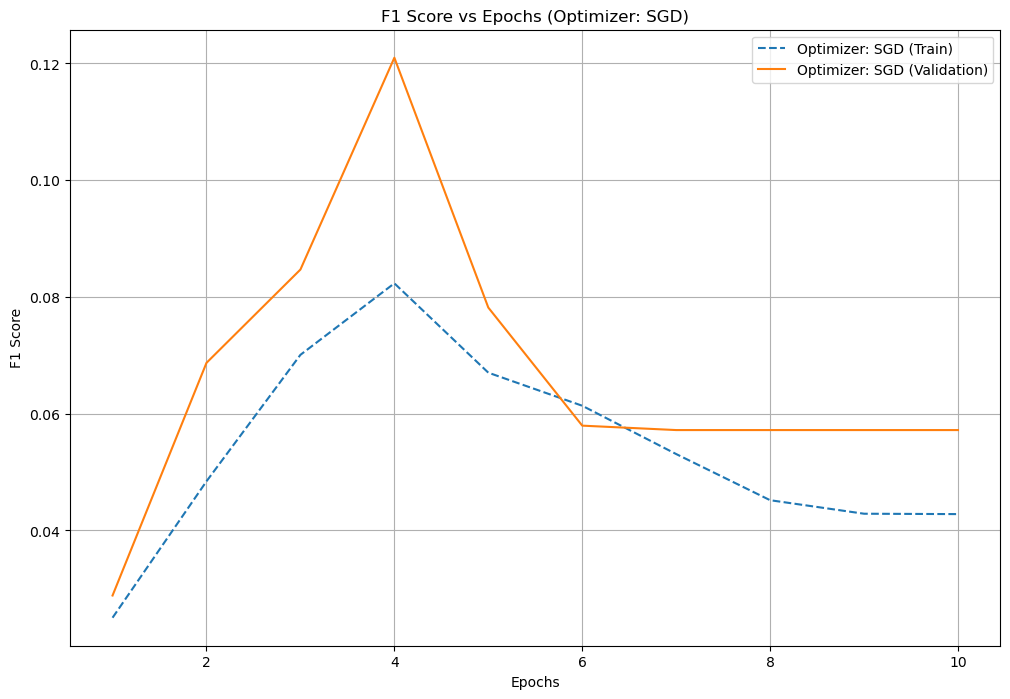

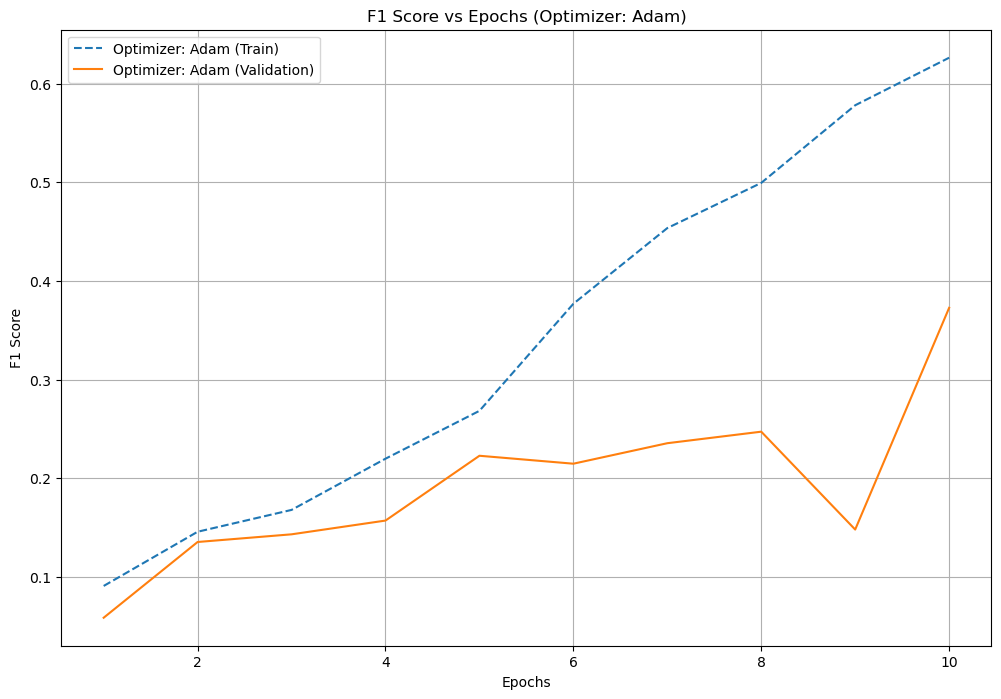

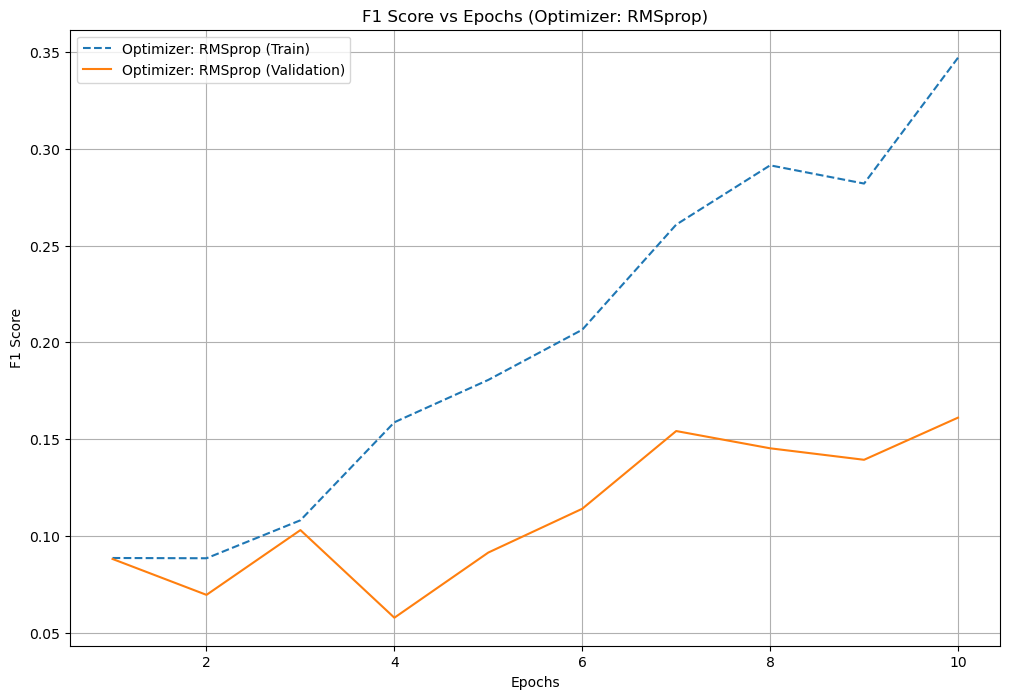

In [80]:
# Plot F1 score vs epochs for training and validation set for each optimizer
for optimizer_name, data in results.items():
    train_f1_scores = data['train_f1_scores']
    val_f1_scores = data['val_f1_scores']
    epochs = range(1, len(train_f1_scores) + 1)
    
    plt.figure(figsize=(12, 8))
    plt.plot(epochs, train_f1_scores, label=f"Optimizer: {optimizer_name} (Train)", linestyle='--')
    plt.plot(epochs, val_f1_scores, label=f"Optimizer: {optimizer_name} (Validation)")
    plt.title(f'F1 Score vs Epochs (Optimizer: {optimizer_name})')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Conclusion
Out of all the optimizers used Adam optimizer has the highest accuracy and it is evident in the graph ven though RMS pro's validation data comes close to the training still there is a disparity in most of the data points,where as Adam gets close to the trained data in majority of the points as it combines the effect of both the SGD with momentum and RMS prop and it also takes the weighted averages of both the first and second moments. So Adam optimizer is better in considering for the accuracy validation

#### g. Calculate the number of trainable parameters in your final model.

In [81]:


# Initialize your model
model = CNN()

# Count the number of parameters in each layer
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)


Total Trainable Parameters: 21331528
